# Poisson Solver Testing - uniform Grid


## Grids Tested

**Angular grids** (fixed across all radii, shared angular mesh):

- **Uniform:**  
  Angles: $\theta_j = \frac{2\pi j}{N}, \qquad j = 0,\dots,N-1.$  


## Method Suite

Four solvers:

- **FFT** (uniform grid only): standard equispaced FFT on the uniform angular mesh, exact and fastest.
- **NUDFT**: direct nonuniform DFT on the random and clustered meshes, solved via regularized least-squares, used as a high-accuracy reference where the frame is not too ill-conditioned.
- **NUFFT (Toeplitz normal-equations):** fast nonuniform transform via FINUFFT, with Fourier coefficients recovered by a Toeplitz/Block-CG solver — a fast Toeplitz operator built from FFT–KDE density weights and a T. Chan circulant preconditioner, solved via Block CG.
- **NUFFT (unsquared PCGLS):** fast nonuniform transform via FINUFFT, with Fourier coefficients recovered by an unsquared PCGLS (Pipe & Menon–style) conjugate-gradient solver on the original normal operator, avoiding spectral squaring.



In [15]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)


# Setup & Configurable Parameters

In [16]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
RADIAL_MAPPING = None       # Non-uniform radial mapping if RAD_UNIF == 0
# Solver Tolerances & Regularization (Lambda)
TOL_NUFFT = 1e-10           # CG residual tolerance for NUFFT
MAXITER_NUFFT = 100         # Maximum CG iterations (50-100 is optimal)
EPS_FINUFFT = 1e-12         # FINUFFT kernel precision (optimal W=10 width)
REG_PARAM = 1e-20           # Regularization parameter
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann


# =============================================================================
# Problem Selection
# =============================================================================
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1, 2: Problem 2
CUSTOM_PROBLEM = None
# Apply global configuration
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    radial_mapping=RADIAL_MAPPING,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    reg_param=REG_PARAM,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM,
)

# =============================================================================
# Grid Sweep Resolutions
# =============================================================================
N_vals_p1 = [32, 64, 128, 256, 512 , 1024, 2048]
M_vals_p1 = [32, 64, 128, 256, 512, 1024, 2048]
N_fixed_p1 = 128


N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]
N_fixed_c = 128
M_fixed_c = 128

MUTE_OUTPUT = True


# Run Problems

In [17]:
# -----------------------------------------------------------------------------
# Methods for Problem 1 Single-Grid Tables (Using Pure Random Grid as the example)
# -----------------------------------------------------------------------------
METHODS_p1 = [
    dict(
        name="Unif-FFT",
        label="Uniform / FFT",
        azu_unif=2,             # uniform azimuthal grid
        mesh_kind="uniform",
        solver_azu_unif=2,      # FFT-based solver
        use_nudft=None,
    ),
    dict(
        name="Unif-NUDFT",
        label="Uniform / NUDFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,      # NUDFT analysis on uniform nodes
        use_nudft=True,
    ),
    dict(
        name="Unif-NUFFT-Toeplitz",
        label="Uniform / NUFFT (Toeplitz)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=2,            # Toeplitz/block–CG path
        use_nudft=False,
    ),
    dict(
        name="Unif-NUFFT-Unsquared",
        label="Uniform / NUFFT (Unsquared)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=3,            # unsquared PCGLS path
        use_nudft=False,
    ),
]

METHODS_COMP = [
    dict(
        name="Unif-FFT",
        label="Uniform / FFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=2,
        use_nudft=None,
    ),
    dict(
        name="Unif-NUDFT",
        label="Uniform / NUDFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        use_nudft=True,
    ),
    dict(
        name="Unif-NUFFT-Toeplitz",
        label="Uniform / NUFFT (Toeplitz)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=2,
        use_nudft=False,
    ),
    dict(
        name="Unif-NUFFT-Unsquared",
        label="Uniform / NUFFT (Unsquared)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=3,
        use_nudft=False,
    ),
]


print("\nRunning Problem 1 - Table 1 (uniform Grid)...")
df_p1_t1 = run_tests_pipeline(N_vals_p1, M_vals_p1, fixed_other=None, methods=METHODS_p1, test_type="P1_Table1", mute=MUTE_OUTPUT)
print("\nRunning Problem 1 - Table 2 (uniform Grid)...")
df_p1_t2 = run_tests_pipeline(None, M_vals_p1, fixed_other=N_fixed_p1, methods=METHODS_p1, test_type="P1_Table2", mute=MUTE_OUTPUT)

print("\nRunning Accuracy Comparisons...")
df_cN = run_tests_pipeline(
    N_vals_c, None,
    fixed_other=M_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryN",
    mute=MUTE_OUTPUT,
)
df_cM = run_tests_pipeline(
    None, M_vals_c,
    fixed_other=N_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryM",
    mute=MUTE_OUTPUT,
)
print("Done.")



Running Problem 1 - Table 1 (uniform Grid)...


Pipeline (P1_Table1): 100%|██████████| 4/4 [02:18<00:00, 34.62s/it, method=Unif-NUFFT-Unsquared]



Running Problem 1 - Table 2 (uniform Grid)...


Pipeline (P1_Table2): 100%|██████████| 4/4 [00:22<00:00,  5.61s/it, method=Unif-NUFFT-Unsquared]



Running Accuracy Comparisons...


Pipeline (Accuracy_VaryM): 100%|██████████| 4/4 [00:01<00:00,  2.66it/s, method=Unif-NUFFT-Unsquared]

Done.


# Accuracy across Meshes

Varying N on the uniform grid — errors should decay rapidly with N for all solvers, with FFT providing the reference.

Accuracy Comparison (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
N,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.55e-07
64,6.55e-07,6.55e-07,6.55e-07,6.55e-07
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,6.55e-07,6.55e-07,6.55e-07,6.55e-07
512,6.55e-07,6.55e-07,6.55e-07,6.55e-07


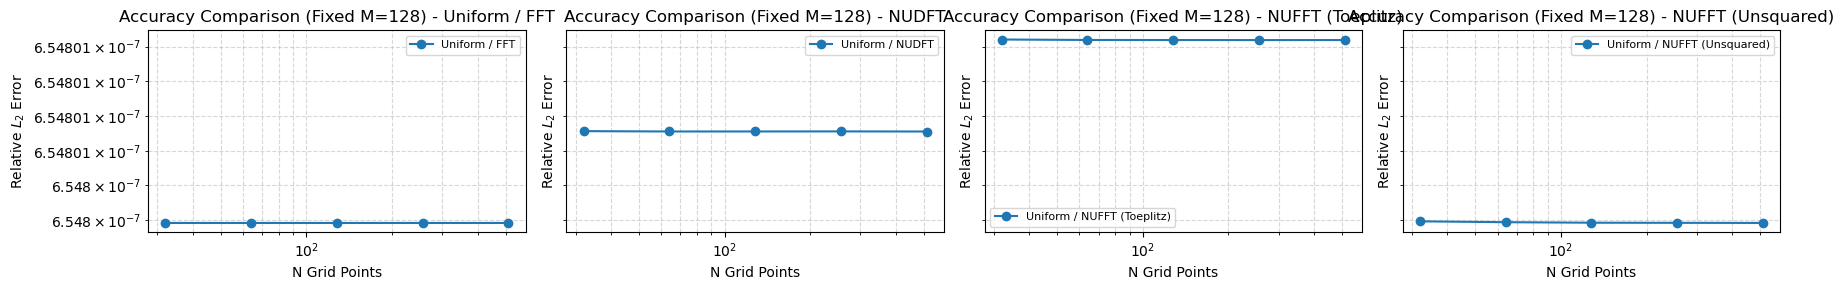

These plots compare NUDFT and the two NUFFT variants against FFT on the uniform azimuthal mesh.
Varying M on the uniform grid — for fixed N, errors should decrease as M increases, reflecting radial convergence.

Accuracy Comparison (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
M,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,4.04e-08


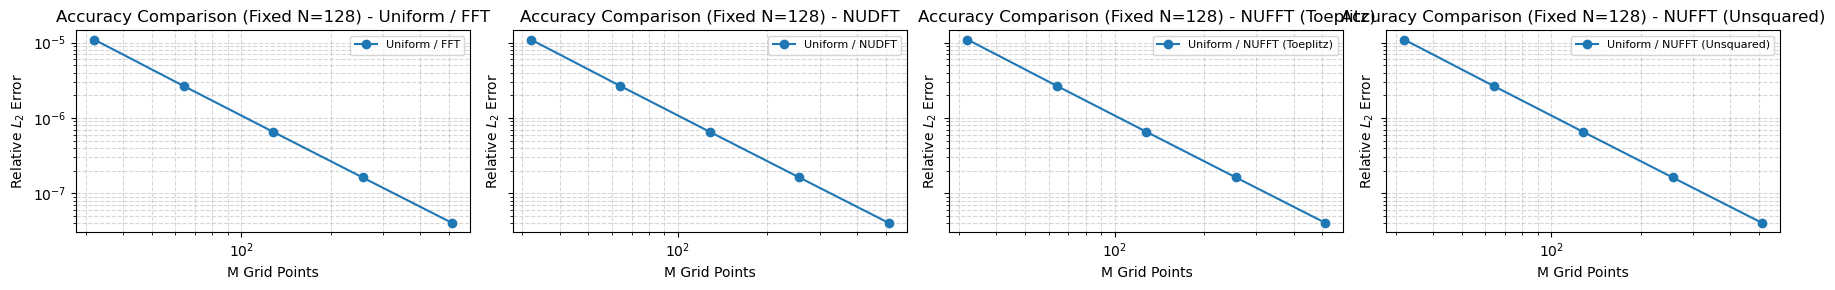

Differences between solvers show how sensitive each algorithm is to radial refinement on the uniform grid.


In [18]:
print("Varying N on the uniform grid — errors should decay rapidly with N for all solvers, with FFT providing the reference.")
render_accuracy(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_accuracy_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
print("These plots compare NUDFT and the two NUFFT variants against FFT on the uniform azimuthal mesh.")

print("Varying M on the uniform grid — for fixed N, errors should decrease as M increases, reflecting radial convergence.")
render_accuracy(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_accuracy_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
print("Differences between solvers show how sensitive each algorithm is to radial refinement on the uniform grid.")

# Accuracy for uniform grid

Problem 1 — Table 1: Relative L2 error over angular and radial resolutions (pure uniform grid)

Problem 1 — Table 1 Accuracy


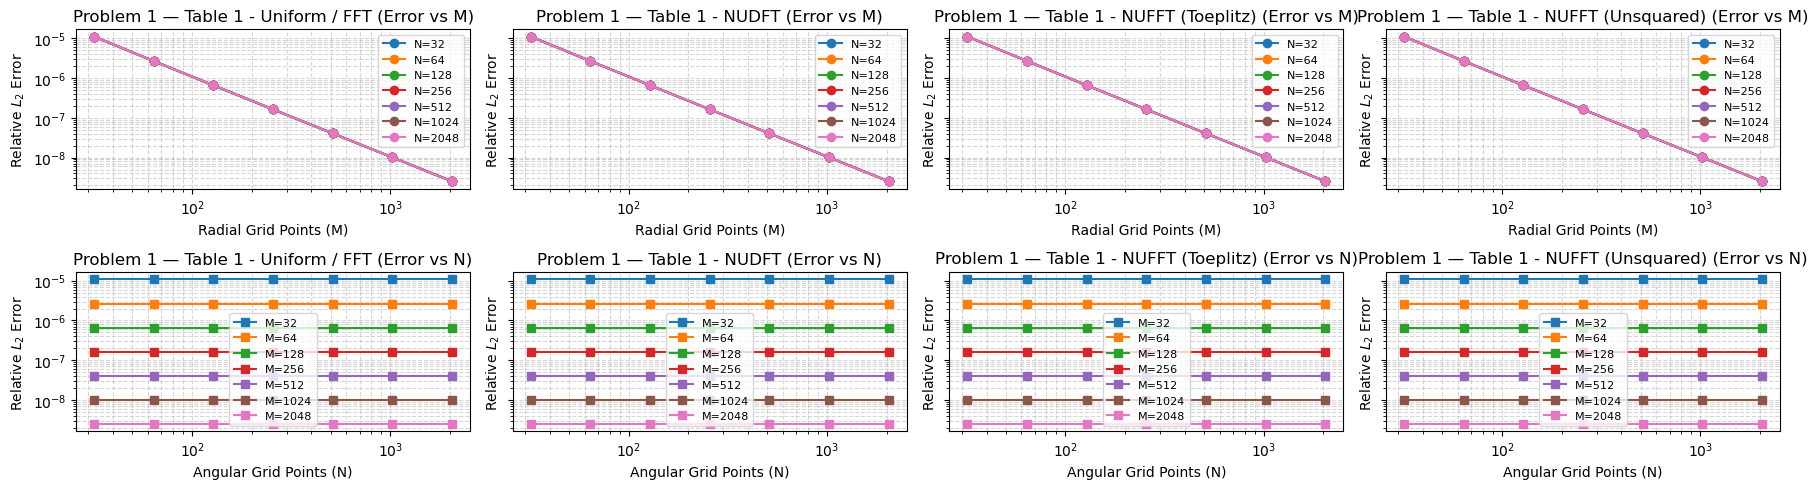

Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N=128, pure uniform grid)

Problem 1 — Table 2 (N=128) Accuracy


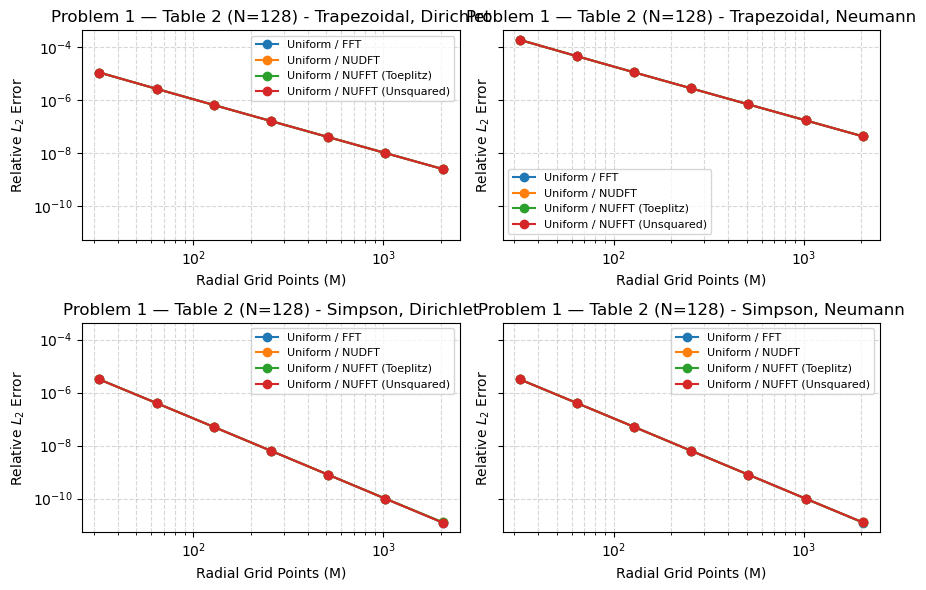

In [19]:
# Accuracy for completely uniform grid (Problem 1)
print("Problem 1 — Table 1: Relative L2 error over angular and radial resolutions (pure uniform grid)")
render_accuracy(df_p1_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 1 — Table 1")
plot_accuracy_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N={N_fixed_p1}, pure uniform grid)")
render_table2_accuracy(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")
plot_accuracy_table2(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")

# Runtimes

Problem 1 — Table 1: Runtimes (pure uniform angular grid)

Problem 1 — Table 1 Runtime (s)


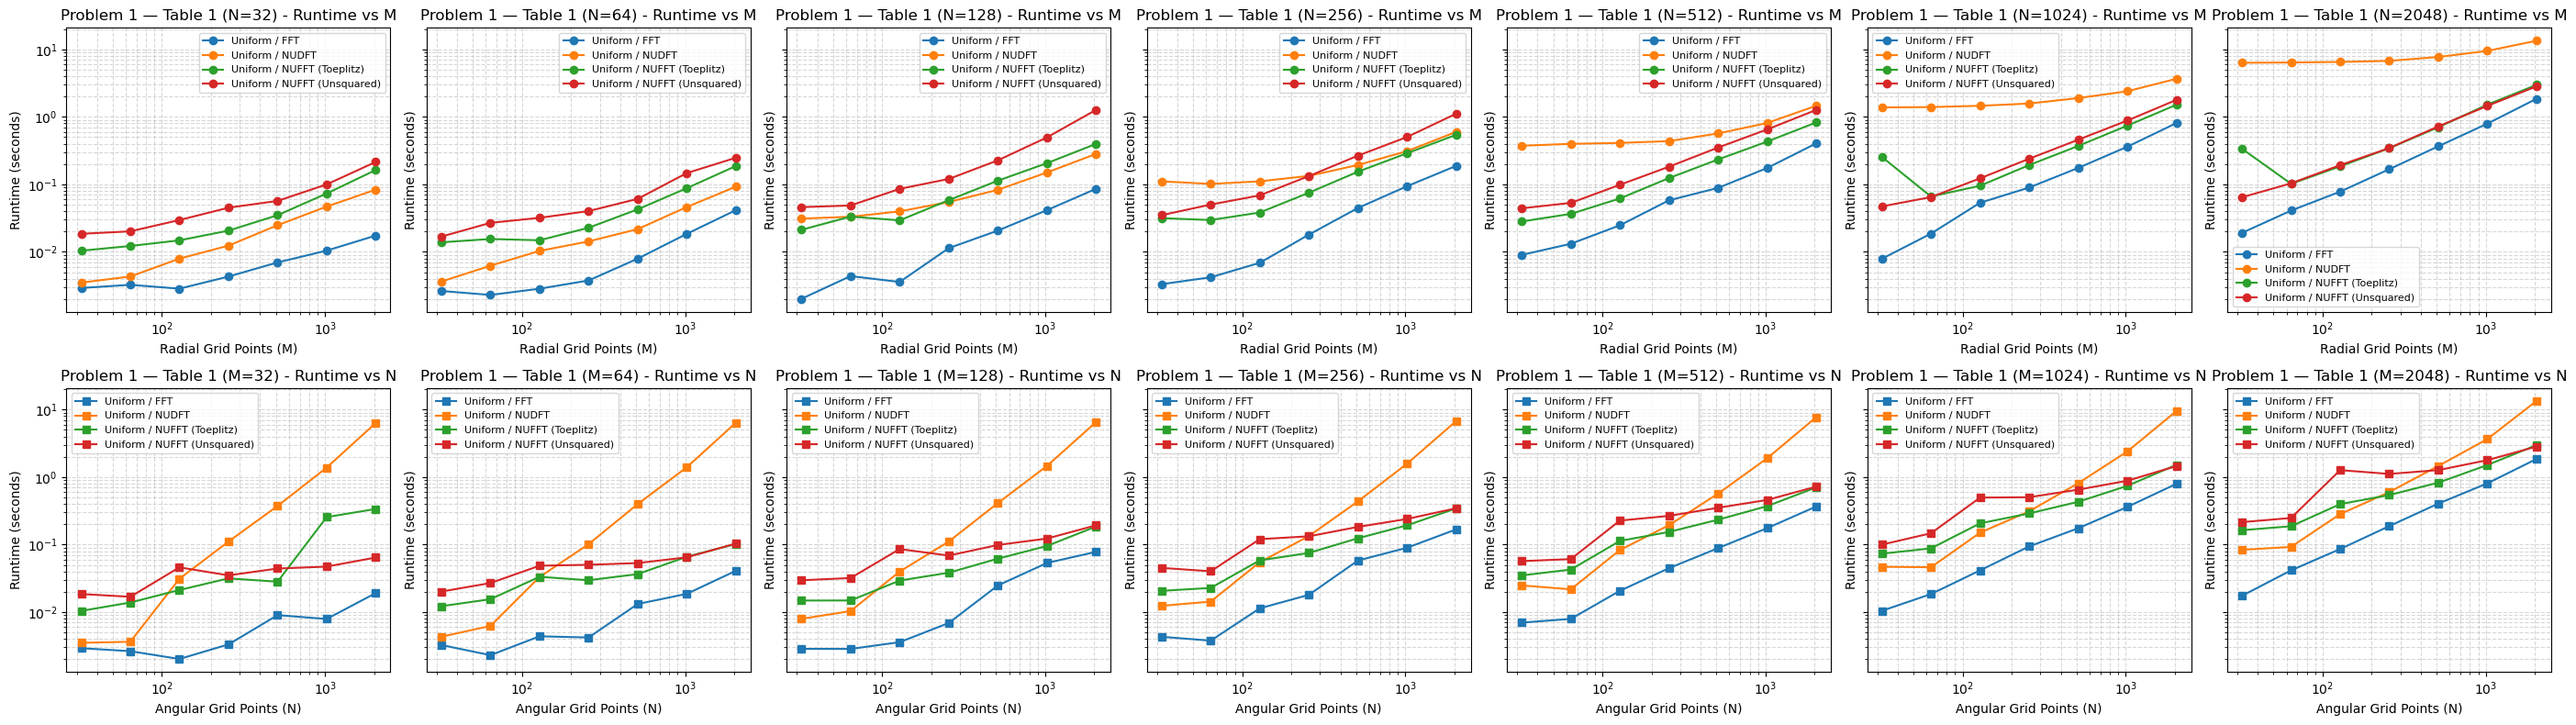

Problem 1 — Table 2: Runtimes (pure uniform angular grid, N=128)

Problem 1 — Table 2 (N=128) Runtime (s)


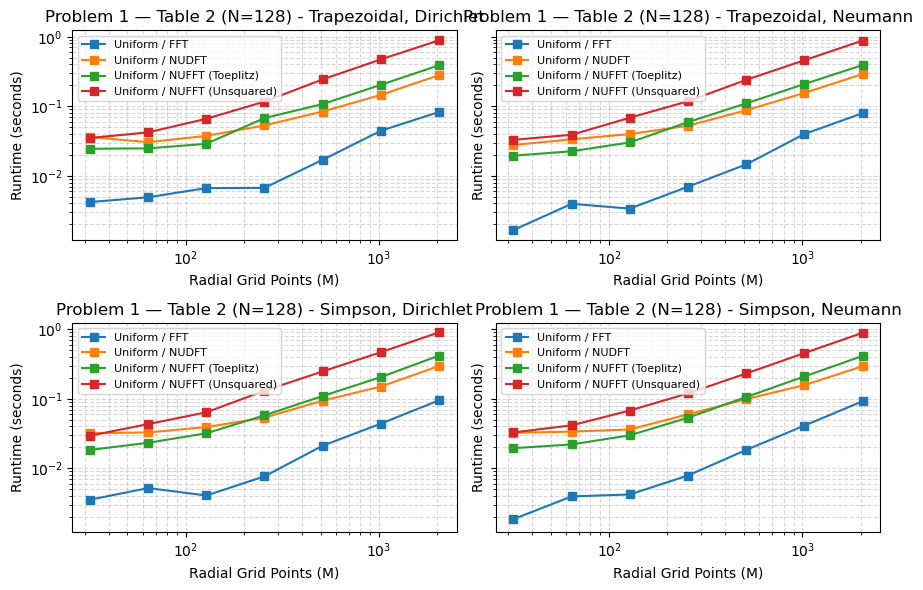

Accuracy Comparison (Fixed M=128) Runtimes

Accuracy Comparison (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
N,,,,
32,0.0018,0.0049,0.0137,0.0237
64,0.0031,0.0093,0.0169,0.0284
128,0.0071,0.0385,0.0295,0.0673
256,0.0119,0.1175,0.0419,0.0744
512,0.0190,0.3784,0.0566,0.0894


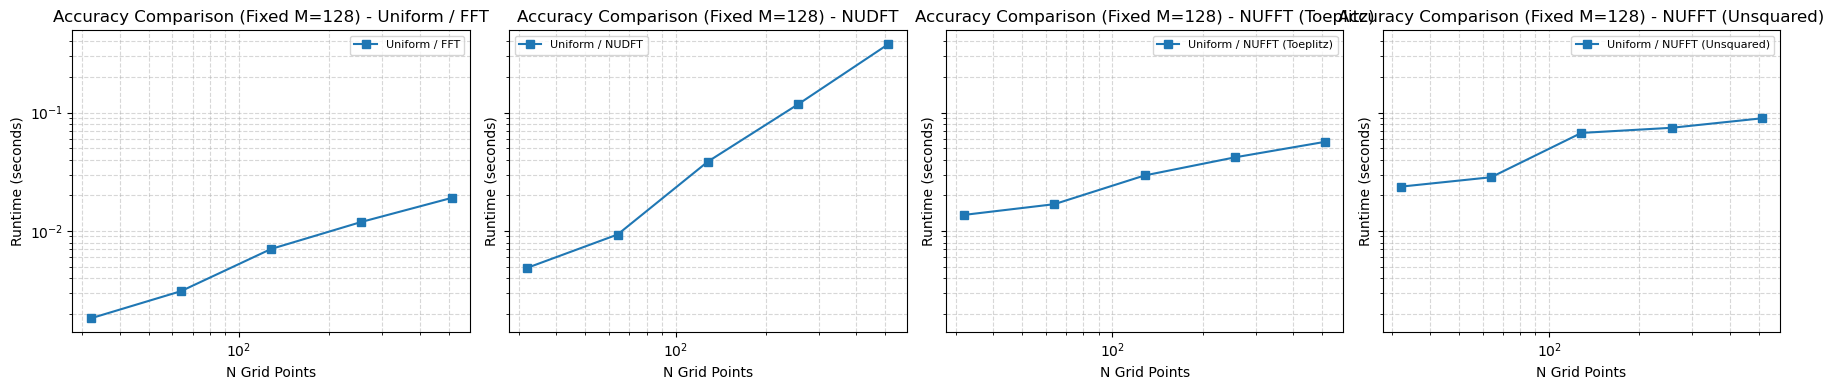

Accuracy Comparison (Fixed N=128) Runtimes

Accuracy Comparison (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
M,,,,
32,0.0033,0.0303,0.0221,0.0352
64,0.0037,0.0325,0.0214,0.0429
128,0.0059,0.0385,0.0276,0.0772
256,0.0080,0.0540,0.0511,0.1205
512,0.0170,0.0829,0.1053,0.2220


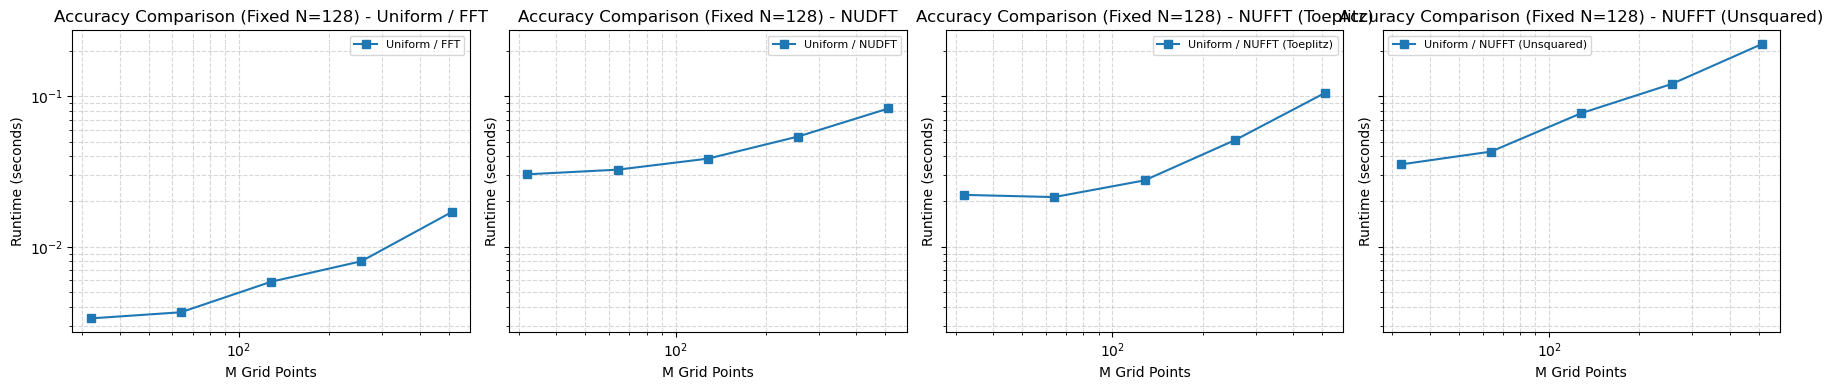

In [20]:

print("Problem 1 — Table 1: Runtimes (pure uniform angular grid)")
render_runtime(df_p1_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 1 — Table 1")
plot_runtime_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"Problem 1 — Table 2: Runtimes (pure uniform angular grid, N={N_fixed_p1})")
render_table2_runtime(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")
plot_runtime_table2(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")


print(f"Accuracy Comparison (Fixed M={M_fixed_c}) Runtimes")
render_runtime(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_runtime_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)

print(f"Accuracy Comparison (Fixed N={N_fixed_c}) Runtimes")
render_runtime(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_runtime_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)

# for paper

Problem 1 — Table 1: Runtimes (pure uniform angular grid)

Problem 1 — Table 1 Runtime (s)


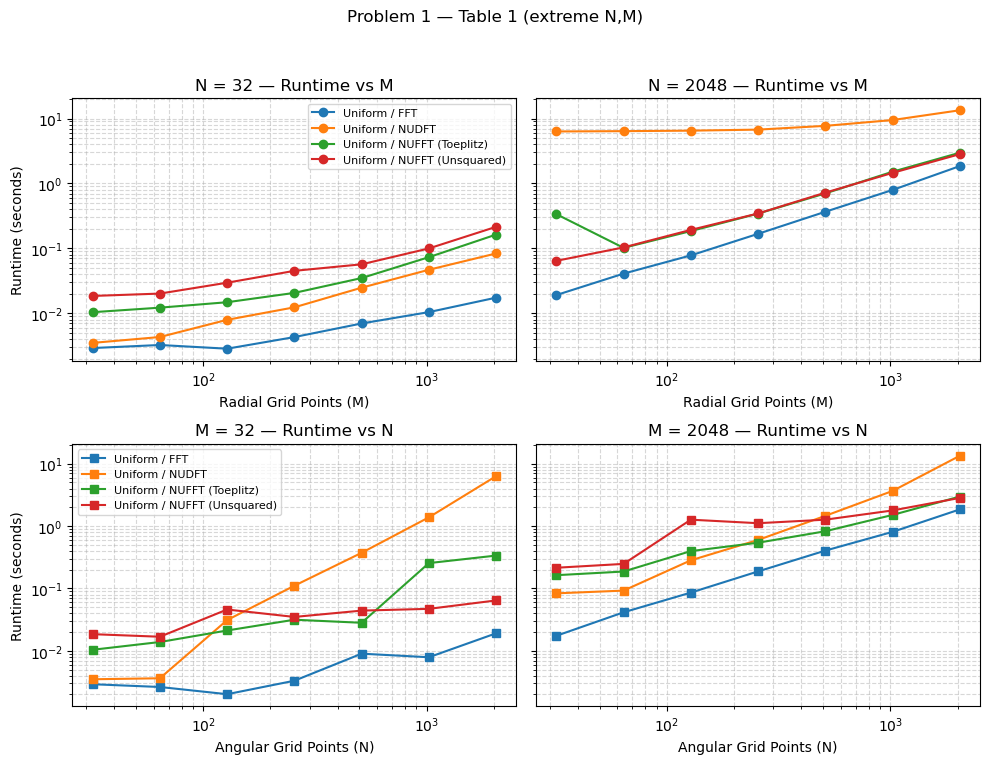

In [21]:
from Tests.CPU.testing_helpers import plot_runtime_table1_extremes



print("Problem 1 — Table 1: Runtimes (pure uniform angular grid)")
render_runtime(df_p1_t1, index_col="N", columns_col=["label", "M"],
               title_prefix="Problem 1 — Table 1")

plot_runtime_table1_extremes(df_p1_t1,
                             title_prefix="Problem 1 — Table 1 (extreme N,M)")

